### Delta-Gamma Hedging Option Position
Using Black-Scholes-Merton we can find the value of an option over time and we can evaluate our position 

We want to hedge a given position to construct a portfolio that is delta-gamma neutral

We can analyze the changes in a day based on the stock movements and see if our hedging strategy worked

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [2]:
def bsm_option(S, K, t, sigma, rf, type='put'):
    """
    S: Underlying asset value
    K: Strike price
    t: time-span of option (annualized)
    sigma: volatility
    rf: risk-free rate (annualized)
    type: type of written option
    """
    d1 = (np.log(S / K) + (rf + 0.5 * sigma**2) * t) / sigma / np.sqrt(t)
    d2 = d1 - sigma * np.sqrt(t)
    pdf_d1 = scipy.stats.norm.pdf(d1)
    
    if type.lower() == 'put':
        cdf_d1 = scipy.stats.norm.cdf(-d1)
        cdf_d2 = scipy.stats.norm.cdf(-d2)
        value = K * np.exp(-rf * t) * cdf_d2 - S * cdf_d1
        delta = - cdf_d1
        gamma = pdf_d1 / S / sigma / np.sqrt(t)
        theta = - S * sigma * pdf_d1 / 2 / np.sqrt(t) + rf * K * np.exp(-rf * t) * cdf_d2
        vega  = S * pdf_d1 * np.sqrt(t)
        rho   = - t * K * np.exp(-rf * t) * cdf_d2
        return {
            'type': type,
            'value': value,
            'delta': delta,
            'gamma': gamma,
            'theta': theta,
            'vega' : vega,
            'rho'  : rho,
            }

    if type.lower() == 'call':
        cdf_d1 = scipy.stats.norm.cdf(d1)
        cdf_d2 = scipy.stats.norm.cdf(d2)
        value = S * cdf_d1 - K * np.exp(-rf * t) * cdf_d2
        delta = cdf_d1
        gamma = pdf_d1 / S / sigma / np.sqrt(t)
        theta = - S * sigma * pdf_d1 / 2 / np.sqrt(t) - rf * K * np.exp(-rf * t) * cdf_d2
        vega  = S * pdf_d1 * np.sqrt(t)
        rho   = t * K * np.exp(-rf * t) * cdf_d2
        return {
            'type': type,
            'value': value,
            'delta': delta,
            'gamma': gamma,
            'theta': theta,
            'vega' : vega,
            'rho'  : rho,
            }

In [10]:
# We are considering the following option
t1 = 90/365
S = 60
K1 = 60
rf = 0.08
sigma = 0.3
typeOption = 'call'

bsm_option(S, K1, t1, sigma, rf, type=typeOption)

{'type': 'call',
 'value': np.float64(4.1445229602782945),
 'delta': np.float64(0.5819565966075844),
 'gamma': np.float64(0.043688491714200604),
 'theta': np.float64(-9.539365484594638),
 'vega': np.float64(11.634305190740545),
 'rho': np.float64(7.587831658235366)}

Suppose we write z = -1000 call options

To build our portfolio we consider another option with the following features

In [11]:
t2 = 60/365
S = 60
K2 = 65
rf = 0.08
sigma = 0.3
typeOption = 'call'

bsm_option(S, K2, t2, sigma, rf, type=typeOption)

{'type': 'call',
 'value': np.float64(1.3782577171980002),
 'delta': np.float64(0.3123732423647997),
 'gamma': np.float64(0.04850151859857283),
 'theta': np.float64(-9.246376958943998),
 'vega': np.float64(8.610680562157588),
 'rho': np.float64(2.854378656113422)}

$$
\begin{align}
V(S) &= x \cdot S + y + z \cdot D_1 + \hat{z} \cdot D_2 \\
\Delta_V &= x + z \cdot \Delta_{D_1} + \hat{z} \cdot \Delta_{D_2} \\
\Gamma_V &= z \cdot \Gamma_{D_1} + \hat{z} \cdot \Gamma_{D_2}
\end{align}
$$

We set $\Delta_V = 0$ and $\Gamma_V = 0$ in order do obtain delta-gamma neutrality

$$
\begin{align}
\hat{z} &=  -z \cdot \frac{\Gamma_{D_1}}{\Gamma_{D_2}} \sim 900.75\\
x &= -z \cdot \Delta_{D_1} + \hat{z} \cdot \Delta_{D_2} \sim 300.59
\end{align}
$$

In addition we can find money position $y$ so that the value of the portfolio is zero

$$
\begin{align}
0 &= x \cdot S + y + z \cdot D_1 + \hat{z} \cdot D_2 \\
y &= -x \cdot S - z \cdot D_1 - \hat{z} \cdot D_2 \sim -15132.2
\end{align}
$$

In [12]:
def portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat):
    daysRemaining_1 = t1 - daysPassed
    daysRemaining_2 = t2 - daysPassed
    valueStocks = x * S
    valueCash = y * np.exp(rf * daysPassed)
    valueOptions_1 = bsm_option(S, K1, daysRemaining_1, sigma, rf, typeOption)['value']
    valueOptions_2 = bsm_option(S, K2, daysRemaining_2, sigma, rf, typeOption)['value']
    return valueStocks + valueCash + z * valueOptions_1 + z_hat * valueOptions_2

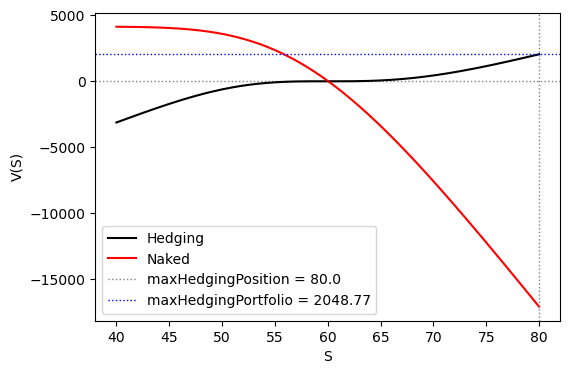

In [20]:
# Analysis of portfolio after 1 day, 89 days remaining
daysPassed = 1/365

# Potential stock values
stockValues = np.linspace(40, 80, 2001)

x, y, z, z_hat = 300.59, -15132.2, -1000, 900.75
hedgingPosition = [portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat) for S in stockValues]

x, y, z, z_hat = 0, 4144.52, -1000, 0
nakedPosition = [portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat) for S in stockValues]


fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(stockValues, hedgingPosition, color='black', label='Hedging')
ax.plot(stockValues, nakedPosition, color='red', label='Naked')

maxHedgingPosition = stockValues[np.argmax(hedgingPosition)]
maxHedgingPortfolio = np.max(hedgingPosition)
ax.axvline(maxHedgingPosition, lw=1, ls=':', color='grey', label=f'maxHedgingPosition = {round(maxHedgingPosition, 2)}')
ax.axhline(maxHedgingPortfolio, lw=1, ls=':', color='blue', label=f'maxHedgingPortfolio = {round(maxHedgingPortfolio, 2)}')
ax.axhline(0, lw=1, ls=':', color='black', alpha=0.5)
ax.set_xlabel('S')
ax.set_ylabel('V(S)')
ax.legend()
plt.show()

`Naked position`: Great movements of the stock price may lead to big gains and even bigger losses

`Hedged position` (delta-gamma neutral): There is a large region of stock price movement that makes our portfolio safe (the flat region around S = 60), in this region the portfolio is highly protected. In addition it is important to notice that big swings in stock price can lead to profit (S > 65) and losses (S < 55). Compared to the delta neutral portfolio, this seems a better choice
